In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
class BasicPositionalEncoding(nn.Module):

    def __init__(self, max_len, embed_size):
        super().__init__()
        self.pos_table = nn.Embedding(max_len, embed_size)
    
    def forward(self, x):
        # (batch_size, seq_len)
        return self.pos_table(torch.arange(x.shape[1])) # (seq_len, embed_size)

In [52]:
class SinCosPositionalEncoding(nn.Module):

    def __init__(self, max_len, embed_size): # embed_size must be even
        super().__init__()
        freqs = torch.zeros(embed_size)
        invs = 1 / (10000 ** (torch.arange(embed_size//2) * 2 / embed_size))
        freqs[::2] = invs
        freqs[1::2] = invs
        pos_embed = torch.arange(max_len, dtype=torch.float)[:, None] @ freqs[None, :] # (max_len, embed_size)
        pos_embed[:, ::2] = torch.sin(pos_embed[:, ::2])
        pos_embed[:, 1::2] = torch.cos(pos_embed[:, 1::2])
        self.register_buffer('pos_table', pos_embed) # (max_len, embed_size)
    
    def forward(self, x):
        # (batch_size, seq_len)
        return self.pos_table[:x.shape[1]]

In [55]:
posenc = SinCosPositionalEncoding(1000, 20)

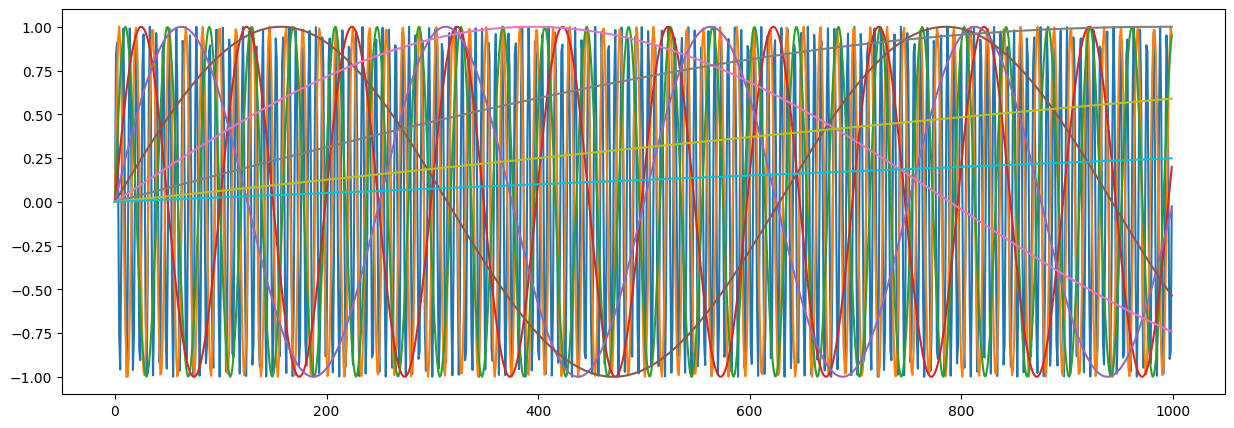

In [59]:
plt.figure(figsize=(15,5))
plt.plot(posenc.pos_table[:, ::2]);